In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from scipy import constants
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [3]:
from labmate.acquisition_notebook import AcquisitionAnalysisManager

In [4]:
from utils.plot_style import set_plot_style 
set_plot_style()

In [5]:
# Some Jupyter instance will not be launched in the root folder of the repository, so we need to change the working directory to access the data and utils modules. We check the current working directory and move up one level if needed.
# Run only once! (if necessary)
print(os.getcwd())
os.chdir('..')
print(os.getcwd())

C:\Users\wilan\PycharmProjects\PANDAManager\plot
C:\Users\wilan\PycharmProjects\PANDAManager


In [5]:
smooth_N = 25

def smooth(y, N):
    kernel = np.ones(N) / N
    return np.convolve(y, kernel, mode="same")

In [6]:
c = constants.c  # speed of light in m/s
L_cav = 500e-3          # m, cavity length
FSR = c / L_cav         # Hz

# Finesse measurements from resonances

### Load data

**OPO**

In [7]:
L_cav = 680e-3          # m, cavity length
FSR = c / L_cav         # Hz

In [8]:
path_folder_data = r"./data/oscilloscope/oscilloscope_trace/2026-08-03_opo_cavity_empty_001"
folder_data_files = os.listdir(path_folder_data)
print(folder_data_files)
name_exp = 'oscilloscope_trace_opo_cavity_empty'
folder_exp_files = os.listdir(os.path.join(path_folder_data, name_exp))
print(folder_exp_files)
name = folder_exp_files[0]  # take the first file in the folder

full_path = os.path.join(path_folder_data, name_exp, name)
aqm = AcquisitionAnalysisManager( os.path.join(path_folder_data, name_exp))
aqm.analysis_cell(filename=full_path)

data = aqm.data
print(data)

['oscilloscope_trace_opo_cavity_empty', 'temp.json']
['2026_08_03__11_17_46__oscilloscope_trace_opo_cavity_empty.h5']


INFO:2026_08_03__11_17_46__oscilloscope_trace_opo_cavity_empty


AnalysisData (rw) (not saved): 
 {
    "CH3_pt_off" (r): "0.000e+00 (type : float64)",
    "CH3_x" (r): "shape: (125000,) (type: ndarray)",
    "CH3_xincr" (r): "1.600e-06 (type : float64)",
    "CH3_xzero" (r): "-0.100 (type : float64)",
    "CH3_y" (r): "shape: (125000,) (type: ndarray)",
    "CH3_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH3_ymult" (r): "4.000e-02 (type : float64)",
    "CH3_yoff" (r): "-39.500 (type : float64)",
    "CH3_yzero" (r): "0.000e+00 (type : float64)",
    "CH4_pt_off" (r): "0.000e+00 (type : float64)",
    "CH4_x" (r): "shape: (125000,) (type: ndarray)",
    "CH4_xincr" (r): "1.600e-06 (type : float64)",
    "CH4_xzero" (r): "-0.100 (type : float64)",
    "CH4_y" (r): "shape: (125000,) (type: ndarray)",
    "CH4_y_raw" (r): "shape: (125000,) (type: ndarray)",
    "CH4_ymult" (r): "4.000e-03 (type : float64)",
    "CH4_yoff" (r): "-4.000 (type : float64)",
    "CH4_yzero" (r): "0.000e+00 (type : float64)",
    "acquisition_cell" (r): {
        

### Set signals variables

**OPO**

In [15]:
time = np.array(data["CH3_x"])
ramp = np.array(data["CH3_y"])
signal = - np.array(data["CH4_y"])

In [16]:
signal = smooth(signal, smooth_N)  # smooth signal to get better estimate of peak centers
signal = signal - np.mean(signal)
ramp = ramp - np.mean(ramp)
ramp_norm = ramp / np.max(np.abs(ramp))
# Smooth norm signal
smooth_ramp = smooth(ramp_norm, smooth_N)

In [17]:
def lorentzian(x, A, x0, gamma, C):
    return A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2) + C


### Find the linear part of the ramp

In [18]:
max_ramp = np.max(ramp)
min_ramp = np.min(ramp)

percent = 0.08
threshold_low = min_ramp + percent * (max_ramp - min_ramp)
threshold_high = max_ramp - percent * (max_ramp - min_ramp)
linear_mask = (ramp > threshold_low) & (ramp < threshold_high)

segments = []
min_segment_length = 1000
in_segment = False

for i, val in enumerate(linear_mask):
    if val and not in_segment:
        start_idx = i
        in_segment = True
    elif (not val or i == len(linear_mask)-1) and in_segment:
        end_idx = i
        in_segment = False
        if end_idx - start_idx >= min_segment_length:
            segments.append((start_idx, end_idx))

print(f"Found {len(segments)} linear windows.")

Found 8 linear windows.


### Plot raw data with peaks and ramp segment highlighted

**OPO**

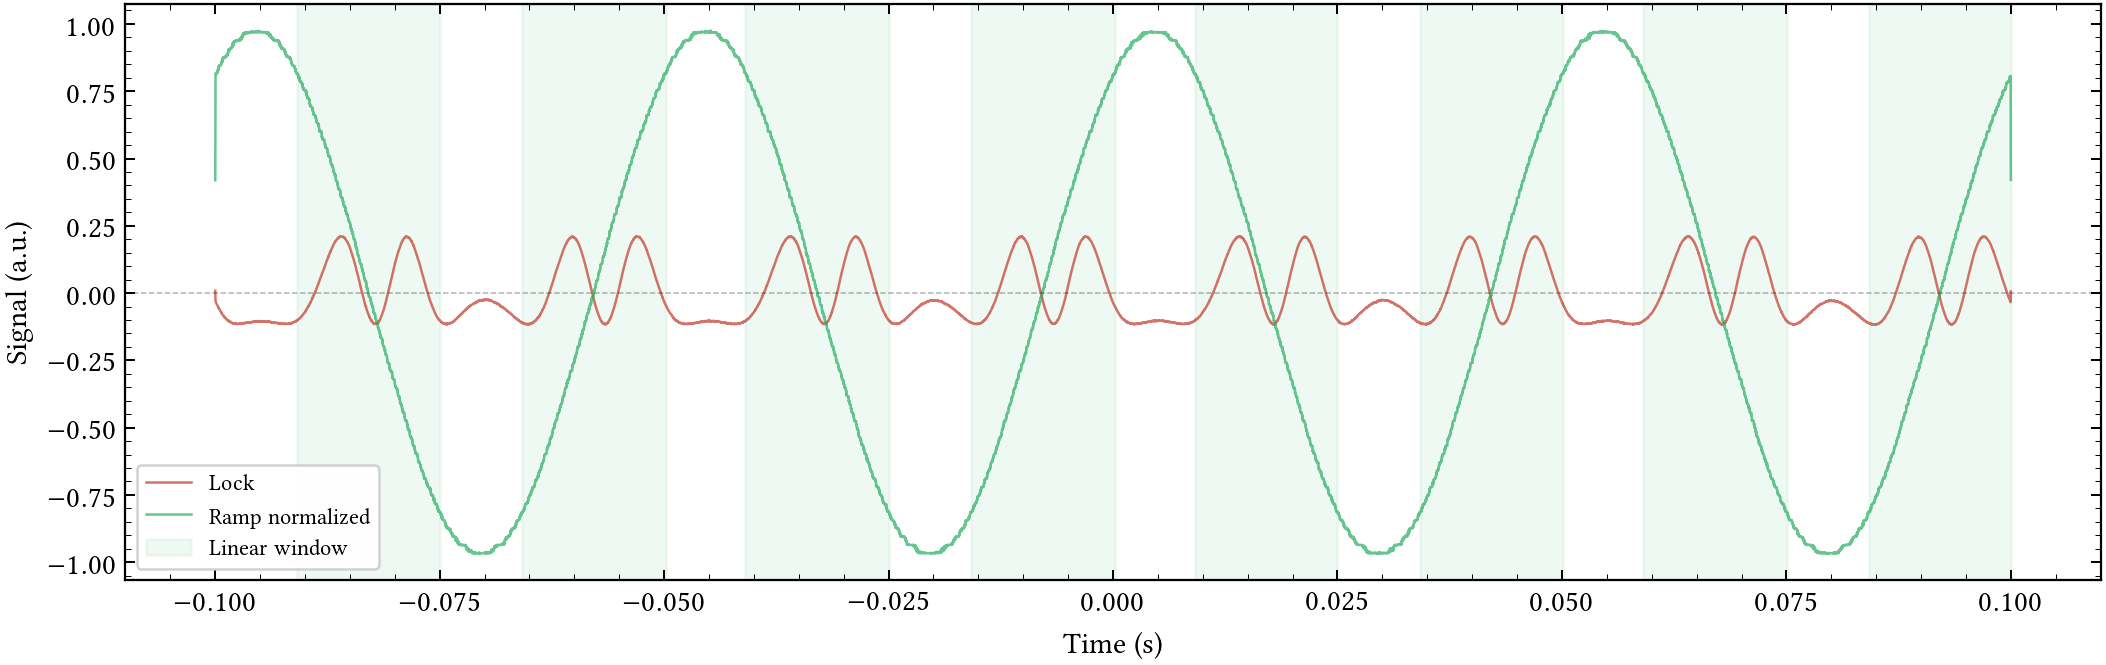

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))

# ax.plot(time, pump,        color="#C0392B", linewidth=1.2, label="Pump")
# ax.plot(time, shg,        color="#2E86AB", linewidth=1.2, label="SHG")
ax.plot(time, signal,        color="#C0392B", linewidth=1.0, alpha=0.7, label="Lock")
ax.plot(time, smooth_ramp, color="#27AE60", linewidth=1.0, alpha=0.7, label="Ramp normalized")

for i, (start_idx, end_idx) in enumerate(segments):
    ax.axvspan(time[start_idx], time[end_idx],
               color="#27AE60", alpha=0.07,
               label="Linear window" if i == 0 else None)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.3)
ax.tick_params(direction="in", top=True, right=True, length=4, width=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Signal (a.u.)")
ax.legend(frameon=True, framealpha=0.9, edgecolor="0.8", fontsize=9)
fig.tight_layout()

### Find peaks and fit Lorentzian

In [18]:
peak_fits = []
all_peaks = []

height = 0.3  # minimum height of peaks, adjust as needed

N = 300  # number of points to take around each peak for fitting, adjust as needed

# first pass: find all peaks
for window_id, (start_idx, end_idx) in enumerate(segments):

    segment_signal = signal[start_idx:end_idx]
    # print(segment_signal.max())
    # print(segment_signal.min())
    peaks, props = find_peaks(
        segment_signal,
        height=height,
        prominence=0.05,
        distance=100  # Minimum distance between peaks
    )

    print(f"Window {window_id}: {len(peaks)} peaks")
    print(np.allclose(segment_signal[peaks],
                  props["peak_heights"]))

    print(segment_signal[peaks])
    print(props["peak_heights"])

    for peak in peaks:
        all_peaks.append((start_idx + peak, window_id))

    

print(f"Total peaks found: {len(all_peaks)}")

# calibration from all detected peaks
peak_times = np.array([time[idx] for idx, window_id in all_peaks])
peak_times = np.sort(peak_times)

time_per_FSR = np.median(np.diff(peak_times))
Hz_per_sec = FSR / time_per_FSR

print(f"time_per_FSR = {time_per_FSR:.3e} s")
print(f"Hz_per_sec   = {Hz_per_sec:.3e} Hz/s")

# second pass: fit all peaks
for idx, window_id in all_peaks:

    if idx - N < 0 or idx + N >= len(signal):
        continue

    xdata = time[idx-N:idx+N]
    ydata = signal[idx-N:idx+N]

    A_guess = np.max(ydata) - np.min(ydata)
    x0_guess = time[idx]
    gamma_guess = 20 * (time[1] - time[0])
    C_guess = np.min(ydata)

    p0 = [A_guess, x0_guess, gamma_guess, C_guess]


    popt, pcov = curve_fit(lorentzian, xdata, ydata, p0=p0)

    A_fit, x0_fit, gamma_fit, C_fit = popt

    gamma_freq = abs(gamma_fit * Hz_per_sec)
    finesse = FSR / gamma_freq

    peak_fits.append({
        "A": A_fit,
        "x0": x0_fit,
        "gamma_time": gamma_fit,
        "gamma_freq": gamma_freq,
        "finesse": finesse,
        "C": C_fit,
        "window_id": window_id,
        "time_per_FSR": time_per_FSR
    })

    # print(window_id,
    #   idx,
    #   signal[idx],
    #   np.max(signal[idx-N:idx+N]))
    
print(f"Fitted {len(peak_fits)} peaks")


Window 0: 0 peaks
True
[]
[]
Window 1: 0 peaks
True
[]
[]
Window 2: 0 peaks
True
[]
[]
Window 3: 0 peaks
True
[]
[]
Window 4: 0 peaks
True
[]
[]
Window 5: 0 peaks
True
[]
[]
Window 6: 0 peaks
True
[]
[]
Window 7: 0 peaks
True
[]
[]
Total peaks found: 0
time_per_FSR = nan s
Hz_per_sec   = nan Hz/s
Fitted 0 peaks


c:\Users\eq15t\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\eq15t\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### Plot fitted curves

Fitted 10 peaks across 21 windows.


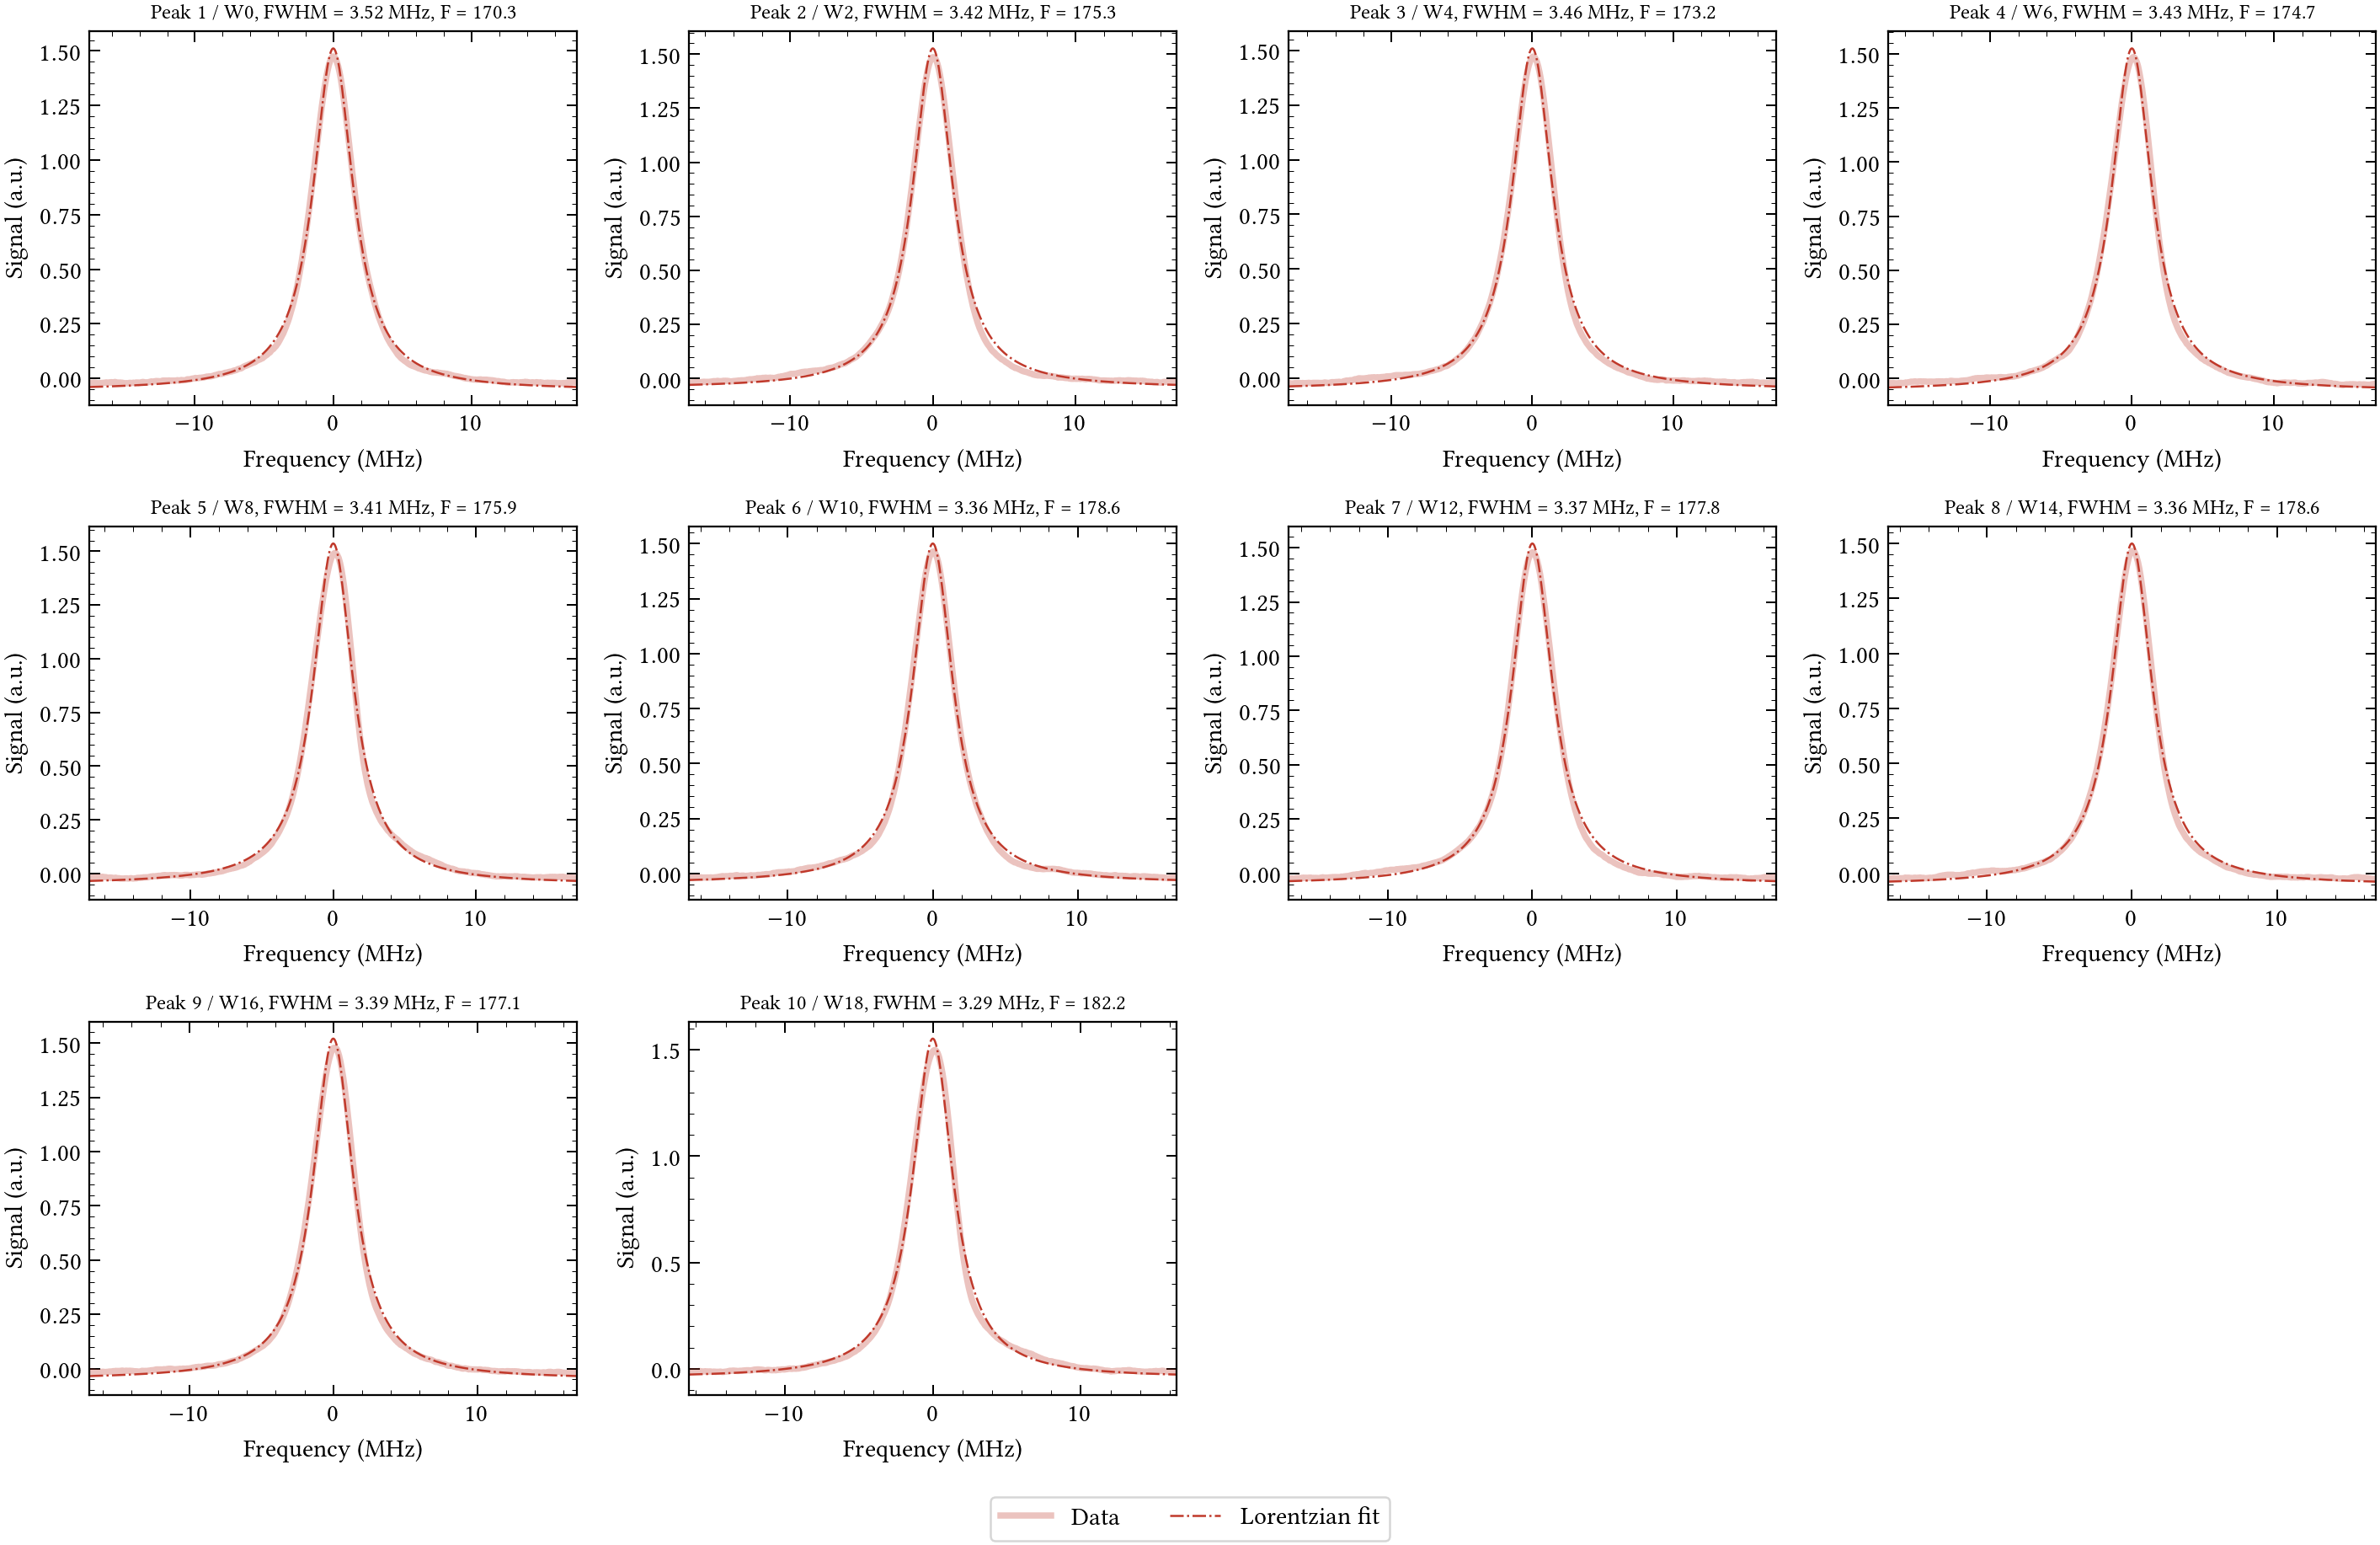

In [18]:
num_peaks = len(peak_fits)
print(f"Fitted {num_peaks} peaks across {len(segments)} windows.")

cols = int(np.ceil(np.sqrt(num_peaks)))
rows = int(np.ceil(num_peaks / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4*cols, 3.5*rows)
)

axes = np.array(axes).reshape(-1)

for i, pf in enumerate(peak_fits):

    ax = axes[i]

    A = pf["A"]
    x0 = pf["x0"]
    gamma_time = pf["gamma_time"]
    gamma_freq = pf["gamma_freq"]
    finesse = pf["finesse"]
    C = pf["C"]

    time_per_FSR = pf["time_per_FSR"]
    Hz_per_sec = FSR / time_per_FSR

    t_fit = np.linspace(
        x0 - 5*abs(gamma_time),
        x0 + 5*abs(gamma_time),
        1000
    )

    y_fit = lorentzian(t_fit, A, x0, gamma_time, C)

    freq_fit = (t_fit - x0) * Hz_per_sec / 1e6
    freq_data = (time - x0) * Hz_per_sec / 1e6

    ax.plot(freq_data, signal, color="#C0392B", alpha=0.3, lw=3.0, label="Data")
    ax.plot(freq_fit, y_fit, color="#C0392B", linestyle="-.", lw=1.0, label="Lorentzian fit")

    ax.set_xlim(freq_fit[0], freq_fit[-1])

    ax.set_title(
        f"Peak {i+1} / W{pf['window_id']}, "
        f"FWHM = {gamma_freq/1e6:.2f} MHz, "
        f"F = {finesse:.1f}",
        fontsize=10
    )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Signal (a.u.)")

# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("./plot/figure/"+"finesse_luke.svg", dpi=300)
plt.show()

### Summary

In [56]:
for i, pf in enumerate(peak_fits):
    print(
        f"Peak {i+1}: "
        f"FWHM = {pf['gamma_freq']/1e6:.3f} MHz, "
        f"Finesse = {pf['finesse']:.1f}"
    )

# Average FWHM and Finesse
gamma_freqs = np.array([pf["gamma_freq"] for pf in peak_fits])
finesses = np.array([pf["finesse"] for pf in peak_fits])
print(f"Average FWHM = {np.mean(gamma_freqs)/1e6:.3f} MHz")
print(f"Average Finesse = {np.mean(finesses):.1f}")

Peak 1: FWHM = 3.520 MHz, Finesse = 170.3
Peak 2: FWHM = 3.420 MHz, Finesse = 175.3
Peak 3: FWHM = 3.462 MHz, Finesse = 173.2
Peak 4: FWHM = 3.432 MHz, Finesse = 174.7
Peak 5: FWHM = 3.408 MHz, Finesse = 175.9
Peak 6: FWHM = 3.356 MHz, Finesse = 178.6
Peak 7: FWHM = 3.372 MHz, Finesse = 177.8
Peak 8: FWHM = 3.358 MHz, Finesse = 178.6
Peak 9: FWHM = 3.386 MHz, Finesse = 177.1
Peak 10: FWHM = 3.291 MHz, Finesse = 182.2
Average FWHM = 3.401 MHz
Average Finesse = 176.4
